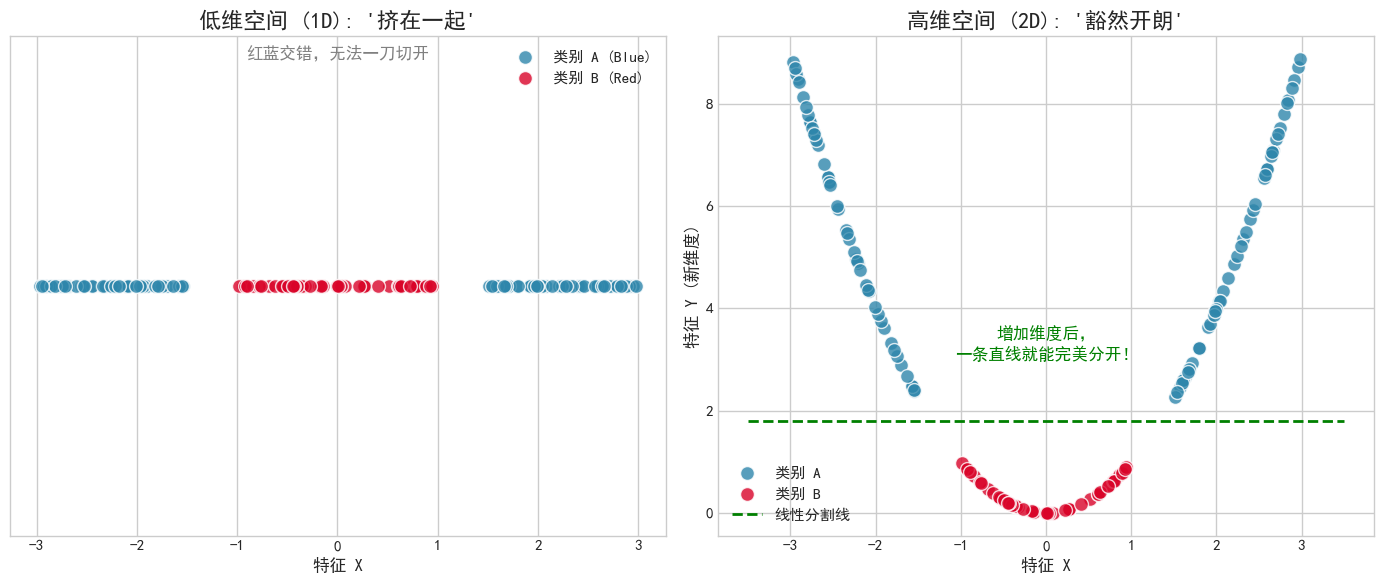

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
#sns.set_theme(style="whitegrid")
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体
matplotlib.rcParams['axes.unicode_minus'] = False    # 解决负号 '-' 显示为方块的问题


plt.style.use('seaborn-v0_8-whitegrid')
#plt.rcParams['font.family'] = 'sans-serif'

plt.rcParams['font.sans-serif'] = ['SimHei'] 

# 1. 创造数据：一维线上“线性不可分”的数据
# 蓝色在两头，红色在中间
np.random.seed(42)
n_samples = 50

# 蓝色数据 (外围)
blue_x_left = np.random.uniform(-3, -1.5, n_samples)
blue_x_right = np.random.uniform(1.5, 3, n_samples)
blue_x = np.concatenate([blue_x_left, blue_x_right])

# 红色数据 (中间)
red_x = np.random.uniform(-1, 1, n_samples)

# 2. 绘图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- 左图：低维空间 (1D) ---
# 为了画图好看，我们把y轴固定为0，只看x轴分布
ax1.set_title("低维空间 (1D): '挤在一起'", fontsize=16, fontweight='bold')
ax1.scatter(blue_x, np.zeros_like(blue_x), c='#2E86AB', s=100, label='类别 A (Blue)', alpha=0.8, edgecolors='white')
ax1.scatter(red_x, np.zeros_like(red_x), c='#D90429', s=100, label='类别 B (Red)', alpha=0.8, edgecolors='white')

# 试图画一条竖线来区分？画不出来的
ax1.set_yticks([]) # 隐藏Y轴，因为是1D
ax1.set_xlabel('特征 X', fontsize=12)
ax1.legend()
ax1.text(0, 0.05, "红蓝交错，无法一刀切开", ha='center', color='gray', fontsize=12)


# --- 右图：高维空间 (2D) ---
# 我们增加一个维度：y = x^2 (模拟升维)
# 这就像FFN中的线性层+非线性变换把数据投射到新空间
ax2.set_title("高维空间 (2D): '豁然开朗'", fontsize=16, fontweight='bold')

# 绘制映射后的点
ax2.scatter(blue_x, blue_x**2, c='#2E86AB', s=100, label='类别 A', alpha=0.8, edgecolors='white')
ax2.scatter(red_x, red_x**2, c='#D90429', s=100, label='类别 B', alpha=0.8, edgecolors='white')

# 现在我们可以画一条直线（线性分类器）把它们分开了！
x_vals = np.linspace(-3.5, 3.5, 100)
decision_boundary = 1.8 # 这是我们的切分高度
ax2.plot(x_vals, [decision_boundary]*100, '--', color='green', linewidth=2, label='线性分割线')

ax2.set_xlabel('特征 X', fontsize=12)
ax2.set_ylabel('特征 Y (新维度)', fontsize=12)
ax2.legend()
ax2.text(0, 3, "增加维度后，\n一条直线就能完美分开！", ha='center', color='green', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

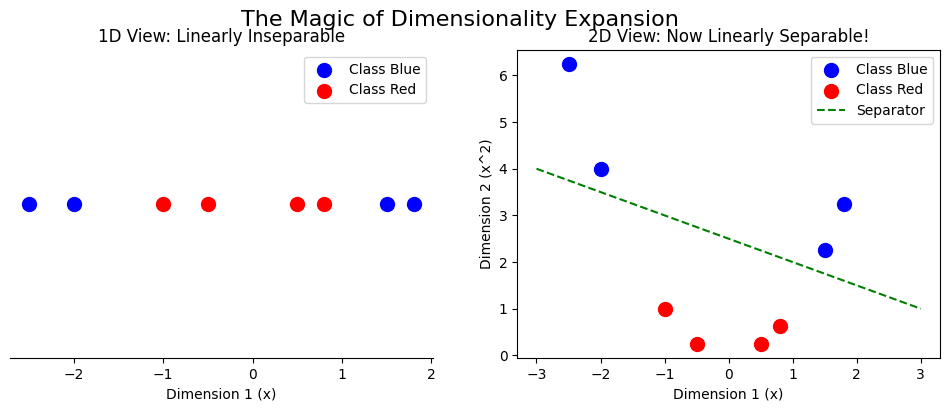

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 在一维空间中创建两组线性不可分的数据
# 蓝点和红点互相交错，无法一刀切开
class_blue_1d = np.array([-2.5, -2, 1.5, 1.8])
class_red_1d = np.array([-1, -0.5, 0.5, 0.8])

# 2. 将一维数据映射到二维空间
# 映射规则: (x) -> (x, x^2)，这是一个非线性映射
def map_to_2d(data):
    return np.stack([data, data**2], axis=1)

class_blue_2d = map_to_2d(class_blue_1d)
class_red_2d = map_to_2d(class_red_1d)

# 3. 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('The Magic of Dimensionality Expansion', fontsize=16)

# 绘制一维图
ax1.set_title('1D View: Linearly Inseparable')
ax1.scatter(class_blue_1d, np.zeros_like(class_blue_1d), c='blue', s=100, label='Class Blue')
ax1.scatter(class_red_1d, np.zeros_like(class_red_1d), c='red', s=100, label='Class Red')
ax1.get_yaxis().set_visible(False) # 隐藏y轴
ax1.spines['left'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlabel('Dimension 1 (x)')
ax1.legend()

# 绘制二维图
ax2.set_title('2D View: Now Linearly Separable!')
ax2.scatter(class_blue_2d[:, 0], class_blue_2d[:, 1], c='blue', s=100, label='Class Blue')
ax2.scatter(class_red_2d[:, 0], class_red_2d[:, 1], c='red', s=100, label='Class Red')
# 画出一条分割线
x_line = np.linspace(-3, 3, 100)
y_line = -0.5 * x_line + 2.5 # 这是一个简单的线性分类器
ax2.plot(x_line, y_line, 'g--', label='Separator')
ax2.set_xlabel('Dimension 1 (x)')
ax2.set_ylabel('Dimension 2 (x^2)')
ax2.legend()

plt.show()